In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv(
    "../data/processed/Global_Population_Cleaned.csv"
)

print("Dataset Shape:", df.shape)
print("Countries:", df["Country Code"].nunique())
print("Year Range:", df["Year"].min(), "-", df["Year"].max())

Dataset Shape: (14292, 6)
Countries: 217
Year Range: 1960 - 2025


In [3]:
df = df.sort_values(
    ["Country Code", "Year"]
).copy()

# Previous year's population
df["Previous_Year_Population"] = (
    df.groupby("Country Code")["Population"].shift(1)
)

# Population from two years ago
df["Population_Lag_2"] = (
    df.groupby("Country Code")["Population"].shift(2)
)

# Average population of previous 3 years
df["Previous_3Year_Avg"] = (
    df.groupby("Country Code")["Population"]
      .transform(
          lambda x: x.shift(1).rolling(
              window=3,
              min_periods=3
          ).mean()
      )
)

print(df[
    [
        "Country Name",
        "Year",
        "Population",
        "Previous_Year_Population",
        "Population_Lag_2",
        "Previous_3Year_Avg"
    ]
].head(10))

    Country Name  Year  Population  Previous_Year_Population  \
594        Aruba  1960     54922.0                       NaN   
595        Aruba  1961     55578.0                   54922.0   
596        Aruba  1962     56320.0                   55578.0   
597        Aruba  1963     57002.0                   56320.0   
598        Aruba  1964     57619.0                   57002.0   
599        Aruba  1965     58190.0                   57619.0   
600        Aruba  1966     58694.0                   58190.0   
601        Aruba  1967     58990.0                   58694.0   
602        Aruba  1968     59069.0                   58990.0   
603        Aruba  1969     59052.0                   59069.0   

     Population_Lag_2  Previous_3Year_Avg  
594               NaN                 NaN  
595               NaN                 NaN  
596           54922.0                 NaN  
597           55578.0        55606.666667  
598           56320.0        56300.000000  
599           57002.0        56

In [4]:
# Remove rows where required lag features are missing
ml_df = df.dropna(
    subset=[
        "Previous_Year_Population",
        "Population_Lag_2",
        "Previous_3Year_Avg"
    ]
).copy()

# Features
features = [
    "Year",
    "Previous_Year_Population",
    "Population_Lag_2",
    "Previous_3Year_Avg"
]

# Target
target = "Population"

X = ml_df[features]
y = ml_df[target]

print("ML Dataset Shape:", ml_df.shape)
print("Features:", features)
print("Target:", target)
print("Missing Values:", X.isna().sum().sum())

ML Dataset Shape: (13641, 9)
Features: ['Year', 'Previous_Year_Population', 'Population_Lag_2', 'Previous_3Year_Avg']
Target: Population
Missing Values: 0


In [5]:
# Train on data up to 2015
train_df = ml_df[
    ml_df["Year"] <= 2015
].copy()

# Validate on the next 5 years: 2016–2020
test_df = ml_df[
    (ml_df["Year"] >= 2016) &
    (ml_df["Year"] <= 2020)
].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training Data:", X_train.shape)
print("Validation Data:", X_test.shape)

print(
    "Training Years:",
    train_df["Year"].min(),
    "-",
    train_df["Year"].max()
)

print(
    "Validation Years:",
    test_df["Year"].min(),
    "-",
    test_df["Year"].max()
)

Training Data: (11471, 4)
Validation Data: (1085, 4)
Training Years: 1963 - 2015
Validation Years: 2016 - 2020


In [6]:
# Create Linear Regression model
validation_model = LinearRegression()

# Train the model
validation_model.fit(X_train, y_train)

# Predict validation period
y_pred = validation_model.predict(X_test)

print("Model training completed successfully.")
print("Number of predictions:", len(y_pred))

Model training completed successfully.
Number of predictions: 1085


In [7]:
# Calculate validation metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Validation Results")
print("------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.6f}")

Validation Results
------------------
MAE  : 35,787.92
RMSE : 126,468.89
R²   : 0.999999


In [8]:
# Select Sri Lanka data
sri_lanka = df[
    df["Country Code"] == "LKA"
].sort_values("Year").copy()

# Historical data up to 2015
history = sri_lanka[
    sri_lanka["Year"] <= 2015
]["Population"].tolist()

recursive_predictions = []

# Predict 2016–2020 recursively
for year in range(2016, 2021):

    lag_1 = history[-1]
    lag_2 = history[-2]
    previous_3_avg = np.mean(history[-3:])

    X_future = pd.DataFrame({
        "Year": [year],
        "Previous_Year_Population": [lag_1],
        "Population_Lag_2": [lag_2],
        "Previous_3Year_Avg": [previous_3_avg]
    })

    prediction = validation_model.predict(X_future)[0]

    recursive_predictions.append({
        "Year": year,
        "Predicted_Population": prediction
    })

    # Add prediction to history
    history.append(prediction)

recursive_predictions_df = pd.DataFrame(
    recursive_predictions
)

print(recursive_predictions_df)

   Year  Predicted_Population
0  2016          2.116213e+07
1  2017          2.135477e+07
2  2018          2.154802e+07
3  2019          2.174183e+07
4  2020          2.193610e+07


In [10]:
# Get actual Sri Lanka population for 2016–2020
actual_sri_lanka = sri_lanka[
    (sri_lanka["Year"] >= 2016) &
    (sri_lanka["Year"] <= 2020)
][
    ["Year", "Population"]
].copy()

# Rename actual population column
actual_sri_lanka.rename(
    columns={"Population": "Actual_Population"},
    inplace=True
)

# Merge actual and predicted values
validation_comparison = actual_sri_lanka.merge(
    recursive_predictions_df,
    on="Year"
)

# Calculate error
validation_comparison["Absolute_Error"] = abs(
    validation_comparison["Actual_Population"]
    - validation_comparison["Predicted_Population"]
)

print(validation_comparison)

   Year  Actual_Population  Predicted_Population  Absolute_Error
0  2016         21209000.0          2.116213e+07    46873.527526
1  2017         21453000.0          2.135477e+07    98226.670414
2  2018         21670000.0          2.154802e+07   121975.859077
3  2019         21803000.0          2.174183e+07    61167.797173
4  2020         21919000.0          2.193610e+07    17097.294690


In [11]:
# Sri Lanka recent population trend
recent_sl = sri_lanka[
    sri_lanka["Year"] >= 2015
][
    ["Year", "Population"]
].copy()

# Calculate annual growth percentage
recent_sl["Growth_Percentage"] = (
    recent_sl["Population"].pct_change() * 100
)

print(recent_sl.to_string(index=False))

 Year  Population  Growth_Percentage
 2015  20970000.0                NaN
 2016  21209000.0           1.139723
 2017  21453000.0           1.150455
 2018  21670000.0           1.011514
 2019  21803000.0           0.613752
 2020  21919000.0           0.532037
 2021  22156000.0           1.081254
 2022  22181000.0           0.112836
 2023  22037000.0          -0.649204
 2024  21916000.0          -0.549077
 2025  21756000.0          -0.730060


In [12]:
# Train model using data up to 2020
recent_train = ml_df[
    ml_df["Year"] <= 2020
].copy()

recent_model = LinearRegression()

recent_model.fit(
    recent_train[features],
    recent_train[target]
)

# Sri Lanka history up to 2020
history = sri_lanka[
    sri_lanka["Year"] <= 2020
]["Population"].tolist()

recent_recursive_predictions = []

# Recursively predict 2021–2025
for year in range(2021, 2026):

    lag_1 = history[-1]
    lag_2 = history[-2]
    previous_3_avg = np.mean(history[-3:])

    X_future = pd.DataFrame({
        "Year": [year],
        "Previous_Year_Population": [lag_1],
        "Population_Lag_2": [lag_2],
        "Previous_3Year_Avg": [previous_3_avg]
    })

    prediction = recent_model.predict(X_future)[0]

    recent_recursive_predictions.append({
        "Year": year,
        "Predicted_Population": prediction
    })

    history.append(prediction)

recent_recursive_df = pd.DataFrame(
    recent_recursive_predictions
)

print(recent_recursive_df)

   Year  Predicted_Population
0  2021          2.202667e+07
1  2022          2.212957e+07
2  2023          2.222910e+07
3  2024          2.232578e+07
4  2025          2.241971e+07


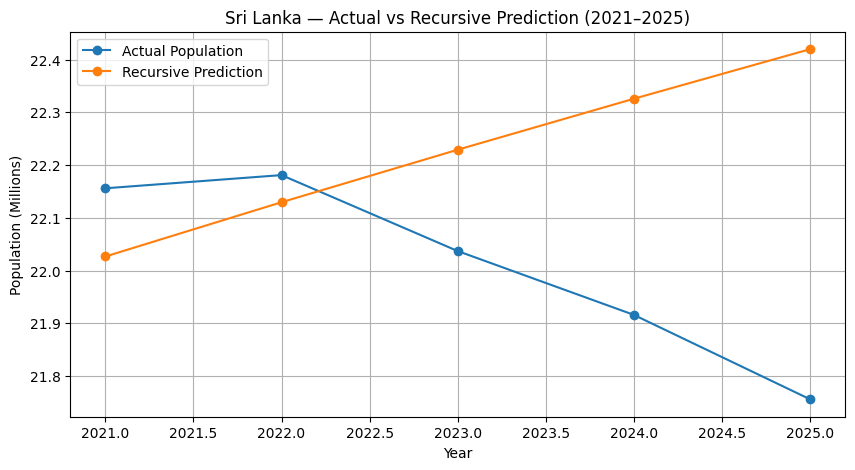

In [13]:
# Merge actual and recursive predictions
recent_actual = sri_lanka[
    (sri_lanka["Year"] >= 2021) &
    (sri_lanka["Year"] <= 2025)
][
    ["Year", "Population"]
].copy()

recent_comparison = recent_actual.merge(
    recent_recursive_df,
    on="Year"
)

# Convert to millions
recent_comparison["Actual_Millions"] = (
    recent_comparison["Population"] / 1e6
)

recent_comparison["Predicted_Millions"] = (
    recent_comparison["Predicted_Population"] / 1e6
)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    recent_comparison["Year"],
    recent_comparison["Actual_Millions"],
    marker="o",
    label="Actual Population"
)

plt.plot(
    recent_comparison["Year"],
    recent_comparison["Predicted_Millions"],
    marker="o",
    label="Recursive Prediction"
)

plt.xlabel("Year")
plt.ylabel("Population (Millions)")
plt.title(
    "Sri Lanka — Actual vs Recursive Prediction (2021–2025)"
)

plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Naive forecast for Sri Lanka
# Next year's prediction = previous year's actual population

naive_predictions = []

for year in range(2021, 2026):

    previous_year_population = sri_lanka[
        sri_lanka["Year"] == year - 1
    ]["Population"].iloc[0]

    naive_predictions.append({
        "Year": year,
        "Actual_Population": sri_lanka[
            sri_lanka["Year"] == year
        ]["Population"].iloc[0],
        "Naive_Prediction": previous_year_population
    })

naive_df = pd.DataFrame(naive_predictions)

naive_df["Absolute_Error"] = abs(
    naive_df["Actual_Population"]
    - naive_df["Naive_Prediction"]
)

print(naive_df)

   Year  Actual_Population  Naive_Prediction  Absolute_Error
0  2021         22156000.0        21919000.0        237000.0
1  2022         22181000.0        22156000.0         25000.0
2  2023         22037000.0        22181000.0        144000.0
3  2024         21916000.0        22037000.0        121000.0
4  2025         21756000.0        21916000.0        160000.0


In [15]:
# Calculate MAE for recursive Linear Regression
recursive_mae = np.mean(
    abs(
        recent_comparison["Population"]
        - recent_comparison["Predicted_Population"]
    )
)

# Calculate MAE for Naive model
naive_mae = naive_df["Absolute_Error"].mean()

print("Model Comparison — Sri Lanka (2021–2025)")
print("------------------------------------------")
print(f"Recursive Linear Regression MAE: {recursive_mae:,.2f}")
print(f"Naive Forecast MAE:              {naive_mae:,.2f}")

Model Comparison — Sri Lanka (2021–2025)
------------------------------------------
Recursive Linear Regression MAE: 289,272.74
Naive Forecast MAE:              137,400.00


In [16]:
# Calculate recent average growth rate
recent_growth = sri_lanka[
    sri_lanka["Year"] >= 2021
]["Population"].pct_change().mean()

print(
    f"Average annual growth rate (2021–2025): "
    f"{recent_growth * 100:.4f}%"
)

# Create growth-rate predictions
growth_predictions = []

current_population = sri_lanka[
    sri_lanka["Year"] == 2020
]["Population"].iloc[0]

for year in range(2021, 2026):

    predicted_population = (
        current_population * (1 + recent_growth)
    )

    actual_population = sri_lanka[
        sri_lanka["Year"] == year
    ]["Population"].iloc[0]

    growth_predictions.append({
        "Year": year,
        "Actual_Population": actual_population,
        "Growth_Rate_Prediction": predicted_population,
        "Absolute_Error": abs(
            actual_population - predicted_population
        )
    })

    current_population = predicted_population

growth_baseline_df = pd.DataFrame(
    growth_predictions
)

print(growth_baseline_df)

Average annual growth rate (2021–2025): -0.4539%
   Year  Actual_Population  Growth_Rate_Prediction  Absolute_Error
0  2021         22156000.0            2.181951e+07   336485.124548
1  2022         22181000.0            2.172048e+07   460518.709793
2  2023         22037000.0            2.162190e+07   415102.805163
3  2024         21916000.0            2.152376e+07   392239.450785
4  2025         21756000.0            2.142607e+07   329930.677529


In [17]:
# Sri Lanka data for country-specific model
sl_ml = ml_df[
    ml_df["Country Code"] == "LKA"
].copy()

print("Sri Lanka ML Data Shape:", sl_ml.shape)

print(
    "Year Range:",
    sl_ml["Year"].min(),
    "-",
    sl_ml["Year"].max()
)

Sri Lanka ML Data Shape: (63, 9)
Year Range: 1963 - 2025


In [18]:
# Split Sri Lanka data into training and validation sets

sl_train = sl_ml[
    sl_ml["Year"] <= 2020
].copy()

sl_test = sl_ml[
    (sl_ml["Year"] >= 2021) &
    (sl_ml["Year"] <= 2025)
].copy()

# Create country-specific Linear Regression model
sl_model = LinearRegression()

sl_model.fit(
    sl_train[features],
    sl_train[target]
)

# Predict 2021–2025
sl_pred = sl_model.predict(
    sl_test[features]
)

print("Sri Lanka-specific model trained successfully.")
print("Training Data:", sl_train.shape)
print("Validation Data:", sl_test.shape)

Sri Lanka-specific model trained successfully.
Training Data: (58, 9)
Validation Data: (5, 9)


In [19]:
# Calculate evaluation metrics

sl_mae = mean_absolute_error(
    sl_test[target],
    sl_pred
)

sl_rmse = np.sqrt(
    mean_squared_error(
        sl_test[target],
        sl_pred
    )
)

sl_r2 = r2_score(
    sl_test[target],
    sl_pred
)

print("Sri Lanka-Specific Model Results")
print("--------------------------------")
print(f"MAE  : {sl_mae:,.2f}")
print(f"RMSE : {sl_rmse:,.2f}")
print(f"R²   : {sl_r2:.6f}")

Sri Lanka-Specific Model Results
--------------------------------
MAE  : 207,701.84
RMSE : 224,334.58
R²   : -1.018939


In [20]:
# Recursive validation for Sri Lanka-specific model

history = sri_lanka[
    sri_lanka["Year"] <= 2020
]["Population"].tolist()

sl_recursive_predictions = []

for year in range(2021, 2026):

    lag_1 = history[-1]
    lag_2 = history[-2]
    previous_3_avg = np.mean(history[-3:])

    X_future = pd.DataFrame({
        "Year": [year],
        "Previous_Year_Population": [lag_1],
        "Population_Lag_2": [lag_2],
        "Previous_3Year_Avg": [previous_3_avg]
    })

    prediction = sl_model.predict(X_future)[0]

    sl_recursive_predictions.append({
        "Year": year,
        "Predicted_Population": prediction
    })

    # Use prediction for the next year's lag
    history.append(prediction)

sl_recursive_df = pd.DataFrame(
    sl_recursive_predictions
)

print(sl_recursive_df)

   Year  Predicted_Population
0  2021          2.208853e+07
1  2022          2.226855e+07
2  2023          2.246110e+07
3  2024          2.265800e+07
4  2025          2.285738e+07


In [21]:
# Get actual Sri Lanka population for 2021–2025

actual_recursive = sri_lanka[
    (sri_lanka["Year"] >= 2021) &
    (sri_lanka["Year"] <= 2025)
][["Year", "Population"]].copy()

actual_recursive.rename(
    columns={"Population": "Actual_Population"},
    inplace=True
)

# Merge actual and predicted values
sl_recursive_comparison = actual_recursive.merge(
    sl_recursive_df,
    on="Year"
)

# Calculate absolute error
sl_recursive_comparison["Absolute_Error"] = abs(
    sl_recursive_comparison["Actual_Population"]
    - sl_recursive_comparison["Predicted_Population"]
)

# Calculate metrics
recursive_mae = mean_absolute_error(
    sl_recursive_comparison["Actual_Population"],
    sl_recursive_comparison["Predicted_Population"]
)

recursive_rmse = np.sqrt(
    mean_squared_error(
        sl_recursive_comparison["Actual_Population"],
        sl_recursive_comparison["Predicted_Population"]
    )
)

recursive_r2 = r2_score(
    sl_recursive_comparison["Actual_Population"],
    sl_recursive_comparison["Predicted_Population"]
)

print("Sri Lanka-Specific Recursive Validation")
print("----------------------------------------")
print(f"MAE  : {recursive_mae:,.2f}")
print(f"RMSE : {recursive_rmse:,.2f}")
print(f"R²   : {recursive_r2:.6f}")

print("\nComparison:")
print(sl_recursive_comparison)

Sri Lanka-Specific Recursive Validation
----------------------------------------
MAE  : 484,499.97
RMSE : 625,407.66
R²   : -14.691233

Comparison:
   Year  Actual_Population  Predicted_Population  Absolute_Error
0  2021         22156000.0          2.208853e+07    6.747492e+04
1  2022         22181000.0          2.226855e+07    8.754813e+04
2  2023         22037000.0          2.246110e+07    4.241009e+05
3  2024         21916000.0          2.265800e+07    7.419976e+05
4  2025         21756000.0          2.285738e+07    1.101378e+06


In [22]:
comparison_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Global Linear Regression",
        "Sri Lanka-Specific Linear Regression"
    ],
    "MAE": [
        137400.00,
        289272.74,
        484499.97
    ]
})

print(comparison_results)

                                  Model        MAE
0                        Naive Baseline  137400.00
1              Global Linear Regression  289272.74
2  Sri Lanka-Specific Linear Regression  484499.97


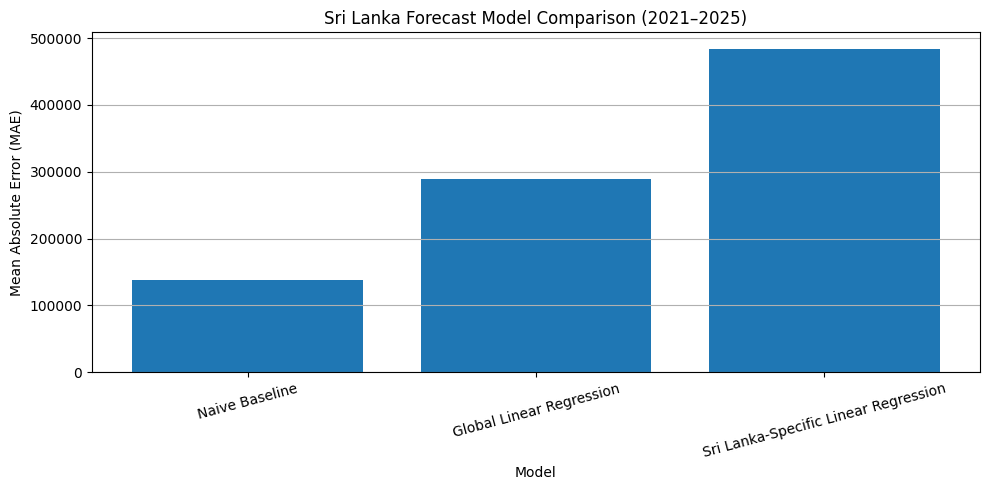

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    comparison_results["Model"],
    comparison_results["MAE"]
)

plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")
plt.title(
    "Sri Lanka Forecast Model Comparison (2021–2025)"
)

plt.xticks(rotation=15)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [24]:
# Save model validation comparison

comparison_results.to_csv(
    "../outputs/tables/sri_lanka_model_validation_comparison.csv",
    index=False
)

print("Validation comparison saved successfully.")
print(
    "../outputs/tables/sri_lanka_model_validation_comparison.csv"
)

Validation comparison saved successfully.
../outputs/tables/sri_lanka_model_validation_comparison.csv


In [25]:
# Train a recent-trend global Linear Regression model

recent_ml_df = ml_df[
    ml_df["Year"] >= 2010
].copy()

recent_global_model = LinearRegression()

recent_global_model.fit(
    recent_ml_df[features],
    recent_ml_df[target]
)

print("Recent-trend global model trained successfully.")
print("Training Data:", recent_ml_df.shape)
print(
    "Training Years:",
    recent_ml_df["Year"].min(),
    "-",
    recent_ml_df["Year"].max()
)

Recent-trend global model trained successfully.
Training Data: (3472, 9)
Training Years: 2010 - 2025


In [26]:
# Recursive validation using the recent-trend global model

history = sri_lanka[
    sri_lanka["Year"] <= 2020
]["Population"].tolist()

recent_global_predictions = []

for year in range(2021, 2026):

    lag_1 = history[-1]
    lag_2 = history[-2]
    previous_3_avg = np.mean(history[-3:])

    X_future = pd.DataFrame({
        "Year": [year],
        "Previous_Year_Population": [lag_1],
        "Population_Lag_2": [lag_2],
        "Previous_3Year_Avg": [previous_3_avg]
    })

    prediction = recent_global_model.predict(X_future)[0]

    recent_global_predictions.append({
        "Year": year,
        "Predicted_Population": prediction
    })

    # Use predicted value for the next year
    history.append(prediction)

recent_global_recursive_df = pd.DataFrame(
    recent_global_predictions
)

print("Recent-Trend Global Recursive Predictions")
print("------------------------------------------")
print(recent_global_recursive_df)

Recent-Trend Global Recursive Predictions
------------------------------------------
   Year  Predicted_Population
0  2021          2.203276e+07
1  2022          2.214576e+07
2  2023          2.225799e+07
3  2024          2.236925e+07
4  2025          2.247936e+07


In [27]:
# Evaluate recent-trend global model

recent_actual = sri_lanka[
    (sri_lanka["Year"] >= 2021) &
    (sri_lanka["Year"] <= 2025)
][["Year", "Population"]].copy()

recent_actual.rename(
    columns={"Population": "Actual_Population"},
    inplace=True
)

recent_comparison = recent_actual.merge(
    recent_global_recursive_df,
    on="Year"
)

recent_mae = mean_absolute_error(
    recent_comparison["Actual_Population"],
    recent_comparison["Predicted_Population"]
)

recent_rmse = np.sqrt(
    mean_squared_error(
        recent_comparison["Actual_Population"],
        recent_comparison["Predicted_Population"]
    )
)

recent_r2 = r2_score(
    recent_comparison["Actual_Population"],
    recent_comparison["Predicted_Population"]
)

print("Recent-Trend Global Recursive Validation")
print("-----------------------------------------")
print(f"MAE  : {recent_mae:,.2f}")
print(f"RMSE : {recent_rmse:,.2f}")
print(f"R²   : {recent_r2:.6f}")

print("\nComparison:")
print(recent_comparison)

Recent-Trend Global Recursive Validation
-----------------------------------------
MAE  : 311,215.05
RMSE : 398,484.04
R²   : -5.370192

Comparison:
   Year  Actual_Population  Predicted_Population
0  2021         22156000.0          2.203276e+07
1  2022         22181000.0          2.214576e+07
2  2023         22037000.0          2.225799e+07
3  2024         21916000.0          2.236925e+07
4  2025         21756000.0          2.247936e+07


In [28]:
# Create annual population growth rate

growth_df = df.sort_values(
    ["Country Code", "Year"]
).copy()

growth_df["Growth_Rate"] = (
    growth_df.groupby("Country Code")["Population"]
    .pct_change()
)

growth_df = growth_df.dropna(
    subset=["Growth_Rate"]
).copy()

print("Growth-rate dataset shape:", growth_df.shape)
print(
    "Growth rate range:",
    growth_df["Growth_Rate"].min(),
    "-",
    growth_df["Growth_Rate"].max()
)

Growth-rate dataset shape: (14075, 10)
Growth rate range: -0.24020594660216066 - 0.24234836266525228


In [29]:
# Prepare Sri Lanka growth-rate data

sl_growth = growth_df[
    growth_df["Country Code"] == "LKA"
].sort_values("Year").copy()

# Use previous year's growth rate as a feature
sl_growth["Previous_Growth_Rate"] = (
    sl_growth["Growth_Rate"].shift(1)
)

sl_growth = sl_growth.dropna(
    subset=["Previous_Growth_Rate"]
).copy()

print("Sri Lanka Growth Dataset Shape:", sl_growth.shape)

print(
    "Year Range:",
    sl_growth["Year"].min(),
    "-",
    sl_growth["Year"].max()
)

print(
    sl_growth[
        [
            "Year",
            "Population",
            "Growth_Rate",
            "Previous_Growth_Rate"
        ]
    ].tail(10)
)

Sri Lanka Growth Dataset Shape: (64, 11)
Year Range: 1962 - 2025
       Year  Population  Growth_Rate  Previous_Growth_Rate
11936  2016  21209000.0     0.011397              0.009241
11937  2017  21453000.0     0.011505              0.011397
11938  2018  21670000.0     0.010115              0.011505
11939  2019  21803000.0     0.006138              0.010115
11940  2020  21919000.0     0.005320              0.006138
11941  2021  22156000.0     0.010813              0.005320
11942  2022  22181000.0     0.001128              0.010813
11943  2023  22037000.0    -0.006492              0.001128
11944  2024  21916000.0    -0.005491             -0.006492
11945  2025  21756000.0    -0.007301             -0.005491


In [30]:
# Split data into training and validation sets

sl_growth_train = sl_growth[
    sl_growth["Year"] <= 2020
].copy()

sl_growth_test = sl_growth[
    (sl_growth["Year"] >= 2021) &
    (sl_growth["Year"] <= 2025)
].copy()

# Features and target

X_growth_train = sl_growth_train[
    ["Year", "Previous_Growth_Rate"]
]

y_growth_train = sl_growth_train[
    "Growth_Rate"
]

X_growth_test = sl_growth_test[
    ["Year", "Previous_Growth_Rate"]
]

y_growth_test = sl_growth_test[
    "Growth_Rate"
]

# Train Linear Regression model

growth_model = LinearRegression()

growth_model.fit(
    X_growth_train,
    y_growth_train
)

print("Growth-rate model trained successfully.")

print(
    "Training Data:",
    X_growth_train.shape
)

print(
    "Validation Data:",
    X_growth_test.shape
)

Growth-rate model trained successfully.
Training Data: (59, 2)
Validation Data: (5, 2)


In [31]:
# Recursive growth-rate prediction for Sri Lanka

current_population = sri_lanka[
    sri_lanka["Year"] == 2020
]["Population"].iloc[0]

previous_growth = sl_growth[
    sl_growth["Year"] == 2020
]["Growth_Rate"].iloc[0]

growth_recursive_predictions = []

for year in range(2021, 2026):

    X_future = pd.DataFrame({
        "Year": [year],
        "Previous_Growth_Rate": [previous_growth]
    })

    predicted_growth = growth_model.predict(
        X_future
    )[0]

    predicted_population = (
        current_population * (1 + predicted_growth)
    )

    growth_recursive_predictions.append({
        "Year": year,
        "Predicted_Growth_Rate": predicted_growth,
        "Predicted_Population": predicted_population
    })

    # Update values for next year
    current_population = predicted_population
    previous_growth = predicted_growth

growth_recursive_df = pd.DataFrame(
    growth_recursive_predictions
)

print("Recursive Growth-Rate Predictions")
print("---------------------------------")
print(growth_recursive_df)

Recursive Growth-Rate Predictions
---------------------------------
   Year  Predicted_Growth_Rate  Predicted_Population
0  2021               0.004006          2.200682e+07
1  2022               0.003322          2.207993e+07
2  2023               0.002862          2.214311e+07
3  2024               0.002480          2.219803e+07
4  2025               0.002127          2.224524e+07


In [32]:
# Get actual Sri Lanka population for 2021–2025

growth_actual = sri_lanka[
    (sri_lanka["Year"] >= 2021) &
    (sri_lanka["Year"] <= 2025)
][["Year", "Population"]].copy()

growth_actual.rename(
    columns={"Population": "Actual_Population"},
    inplace=True
)

# Merge actual and predicted values

growth_comparison = growth_actual.merge(
    growth_recursive_df,
    on="Year"
)

# Calculate absolute error

growth_comparison["Absolute_Error"] = abs(
    growth_comparison["Actual_Population"]
    - growth_comparison["Predicted_Population"]
)

# Calculate metrics

growth_mae = mean_absolute_error(
    growth_comparison["Actual_Population"],
    growth_comparison["Predicted_Population"]
)

growth_rmse = np.sqrt(
    mean_squared_error(
        growth_comparison["Actual_Population"],
        growth_comparison["Predicted_Population"]
    )
)

growth_r2 = r2_score(
    growth_comparison["Actual_Population"],
    growth_comparison["Predicted_Population"]
)

print("Growth-Rate Model Recursive Validation")
print("--------------------------------------")
print(f"MAE  : {growth_mae:,.2f}")
print(f"RMSE : {growth_rmse:,.2f}")
print(f"R²   : {growth_r2:.6f}")

print("\nComparison:")
print(growth_comparison)

Growth-Rate Model Recursive Validation
--------------------------------------
MAE  : 225,527.02
RMSE : 269,305.45
R²   : -1.909517

Comparison:
   Year  Actual_Population  Predicted_Growth_Rate  Predicted_Population  \
0  2021         22156000.0               0.004006          2.200682e+07   
1  2022         22181000.0               0.003322          2.207993e+07   
2  2023         22037000.0               0.002862          2.214311e+07   
3  2024         21916000.0               0.002480          2.219803e+07   
4  2025         21756000.0               0.002127          2.224524e+07   

   Absolute_Error  
0   149182.463238  
1   101069.662925  
2   106113.030303  
3   282029.949789  
4   489239.993508  


In [33]:
# Train final Sri Lanka growth-rate model using all available data

sl_growth_final = sl_growth.copy()

X_final_growth = sl_growth_final[
    ["Year", "Previous_Growth_Rate"]
]

y_final_growth = sl_growth_final[
    "Growth_Rate"
]

final_growth_model = LinearRegression()

final_growth_model.fit(
    X_final_growth,
    y_final_growth
)

print("Final growth-rate model trained successfully.")
print("Training Data:", X_final_growth.shape)
print(
    "Training Years:",
    sl_growth_final["Year"].min(),
    "-",
    sl_growth_final["Year"].max()
)

Final growth-rate model trained successfully.
Training Data: (64, 2)
Training Years: 1962 - 2025


In [34]:
# Recursive future population prediction for Sri Lanka
# Using the final growth-rate model

current_population = sri_lanka[
    sri_lanka["Year"] == 2025
]["Population"].iloc[0]

previous_growth = sl_growth[
    sl_growth["Year"] == 2025
]["Growth_Rate"].iloc[0]

future_sl_predictions = []

for year in range(2026, 2036):

    X_future = pd.DataFrame({
        "Year": [year],
        "Previous_Growth_Rate": [previous_growth]
    })

    predicted_growth = final_growth_model.predict(
        X_future
    )[0]

    predicted_population = (
        current_population *
        (1 + predicted_growth)
    )

    future_sl_predictions.append({
        "Year": year,
        "Predicted_Growth_Rate": predicted_growth,
        "Predicted_Population": predicted_population
    })

    # Update values for next year
    current_population = predicted_population
    previous_growth = predicted_growth

future_sl_df = pd.DataFrame(
    future_sl_predictions
)

print("Sri Lanka Future Population Predictions")
print("----------------------------------------")
print(future_sl_df)

Sri Lanka Future Population Predictions
----------------------------------------
   Year  Predicted_Growth_Rate  Predicted_Population
0  2026              -0.002913          2.169261e+07
1  2027              -0.001454          2.166106e+07
2  2028              -0.001124          2.163671e+07
3  2029              -0.001229          2.161012e+07
4  2030              -0.001501          2.157768e+07
5  2031              -0.001838          2.153802e+07
6  2032              -0.002200          2.149063e+07
7  2033              -0.002572          2.143536e+07
8  2034              -0.002947          2.137219e+07
9  2035              -0.003324          2.130115e+07


In [35]:
# Calculate overall change from 2025 to 2035

population_2025 = sri_lanka[
    sri_lanka["Year"] == 2025
]["Population"].iloc[0]

population_2035 = future_sl_df[
    future_sl_df["Year"] == 2035
]["Predicted_Population"].iloc[0]

total_change = (
    population_2035 - population_2025
)

percentage_change = (
    total_change / population_2025
) * 100

print("Sri Lanka 2025–2035 Forecast Summary")
print("-------------------------------------")
print(f"2025 Actual Population : {population_2025:,.0f}")
print(f"2035 Predicted Population : {population_2035:,.0f}")
print(f"Population Change : {total_change:,.0f}")
print(f"Percentage Change : {percentage_change:.2f}%")

Sri Lanka 2025–2035 Forecast Summary
-------------------------------------
2025 Actual Population : 21,756,000
2035 Predicted Population : 21,301,152
Population Change : -454,848
Percentage Change : -2.09%


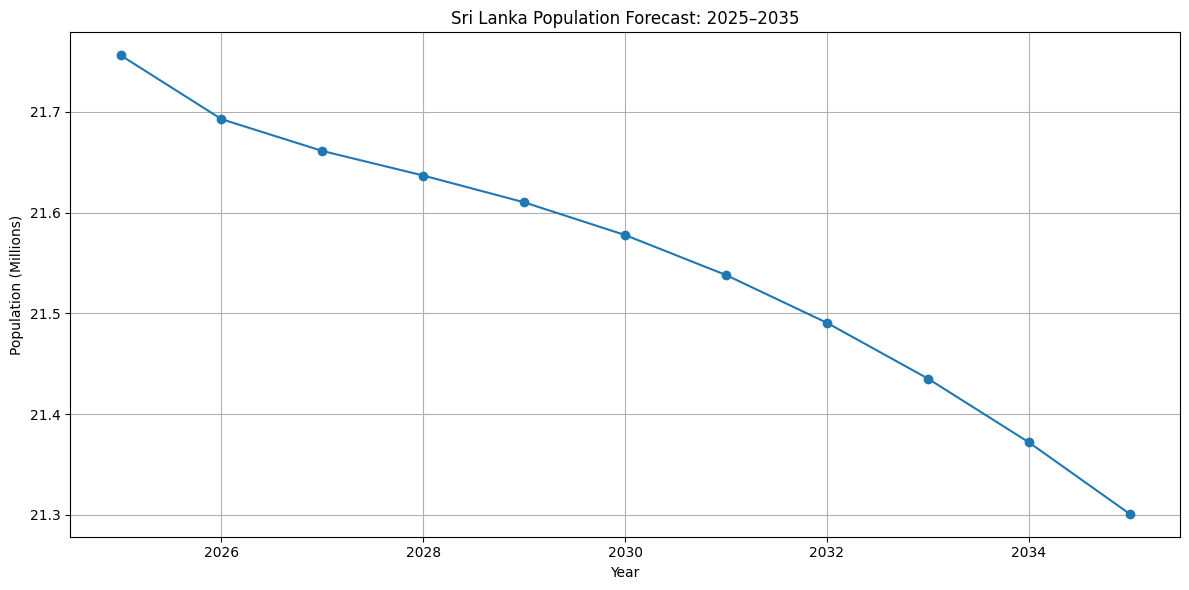

In [36]:
# Combine 2025 actual with 2026–2035 predictions

forecast_chart_df = pd.concat([
    pd.DataFrame({
        "Year": [2025],
        "Population": [population_2025],
        "Type": ["Actual"]
    }),
    pd.DataFrame({
        "Year": future_sl_df["Year"],
        "Population": future_sl_df["Predicted_Population"],
        "Type": ["Predicted"] * len(future_sl_df)
    })
], ignore_index=True)

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_chart_df["Year"],
    forecast_chart_df["Population"] / 1e6,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Population (Millions)")
plt.title(
    "Sri Lanka Population Forecast: 2025–2035"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
# Save Sri Lanka 2026–2035 future predictions

future_sl_df.to_csv(
    "../outputs/tables/sri_lanka_population_forecast_2026_2035.csv",
    index=False
)

print("Sri Lanka future forecast saved successfully.")
print(
    "../outputs/tables/sri_lanka_population_forecast_2026_2035.csv"
)

Sri Lanka future forecast saved successfully.
../outputs/tables/sri_lanka_population_forecast_2026_2035.csv


In [38]:
# Final comparison of all tested forecasting approaches

final_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Global Linear Regression",
        "Recent-Trend Global Linear Regression",
        "Sri Lanka-Specific Linear Regression",
        "Growth-Rate Model"
    ],
    "MAE": [
        137400.00,
        289272.74,
        311215.05,
        484499.97,
        225527.02
    ]
})

final_comparison = final_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

print("Final Model Validation Comparison")
print("----------------------------------")
print(final_comparison)

Final Model Validation Comparison
----------------------------------
                                   Model        MAE
0                         Naive Baseline  137400.00
1                      Growth-Rate Model  225527.02
2               Global Linear Regression  289272.74
3  Recent-Trend Global Linear Regression  311215.05
4   Sri Lanka-Specific Linear Regression  484499.97


In [39]:
# Save final model validation results

final_comparison.to_csv(
    "../outputs/tables/final_model_validation_results.csv",
    index=False
)

print("Final validation results saved successfully.")
print(
    "../outputs/tables/final_model_validation_results.csv"
)

Final validation results saved successfully.
../outputs/tables/final_model_validation_results.csv


In [40]:
# Global validation period
global_train = ml_df[ml_df["Year"] <= 2020].copy()
global_test = ml_df[
    (ml_df["Year"] >= 2021) &
    (ml_df["Year"] <= 2025)
].copy()

print("Training Shape:", global_train.shape)
print("Validation Shape:", global_test.shape)
print("Countries:", global_test["Country Code"].nunique())
print("Validation Years:", global_test["Year"].min(), "-", global_test["Year"].max())

Training Shape: (12556, 9)
Validation Shape: (1085, 9)
Countries: 217
Validation Years: 2021 - 2025


In [41]:
# Train Global Linear Regression Model
global_model = LinearRegression()

global_model.fit(
    global_train[features],
    global_train[target]
)

# Predict validation period
global_pred = global_model.predict(
    global_test[features]
)

# Evaluation metrics
global_mae = mean_absolute_error(
    global_test[target],
    global_pred
)

global_rmse = np.sqrt(
    mean_squared_error(
        global_test[target],
        global_pred
    )
)

global_r2 = r2_score(
    global_test[target],
    global_pred
)

print("Global Linear Regression Validation Results")
print("-------------------------------------------")
print(f"MAE  : {global_mae:,.2f}")
print(f"RMSE : {global_rmse:,.2f}")
print(f"R²   : {global_r2:.6f}")

Global Linear Regression Validation Results
-------------------------------------------
MAE  : 60,514.59
RMSE : 243,507.42
R²   : 0.999997


In [42]:
# Global Naive Baseline
# Prediction = Previous Year's Population

naive_global = global_test["Previous_Year_Population"]

naive_global_mae = mean_absolute_error(
    global_test["Population"],
    naive_global
)

naive_global_rmse = np.sqrt(
    mean_squared_error(
        global_test["Population"],
        naive_global
    )
)

naive_global_r2 = r2_score(
    global_test["Population"],
    naive_global
)

print("Global Naive Baseline Results")
print("-----------------------------")
print(f"MAE  : {naive_global_mae:,.2f}")
print(f"RMSE : {naive_global_rmse:,.2f}")
print(f"R²   : {naive_global_r2:.6f}")

Global Naive Baseline Results
-----------------------------
MAE  : 379,270.56
RMSE : 1,110,642.20
R²   : 0.999939


In [43]:
global_model_comparison = pd.DataFrame({
    "Model": [
        "Global Naive Baseline",
        "Global Linear Regression"
    ],
    "MAE": [
        naive_global_mae,
        global_mae
    ],
    "RMSE": [
        naive_global_rmse,
        global_rmse
    ],
    "R2": [
        naive_global_r2,
        global_r2
    ]
})

print(global_model_comparison)

global_model_comparison.to_csv(
    "../outputs/tables/global_model_validation_comparison.csv",
    index=False
)

print("\nGlobal model validation results saved successfully.")

                      Model            MAE          RMSE        R2
0     Global Naive Baseline  379270.564055  1.110642e+06  0.999939
1  Global Linear Regression   60514.588716  2.435074e+05  0.999997

Global model validation results saved successfully.


In [44]:
# Final Global Linear Regression Model

final_global_model = LinearRegression()

final_global_model.fit(
    ml_df[features],
    ml_df[target]
)

print("Final Global Linear Regression Model trained successfully.")
print("Training Years:", ml_df["Year"].min(), "-", ml_df["Year"].max())
print("Countries:", ml_df["Country Code"].nunique())
print("Training Records:", len(ml_df))

Final Global Linear Regression Model trained successfully.
Training Years: 1963 - 2025
Countries: 217
Training Records: 13641


In [45]:
# Prepare latest historical data
forecast_base = df.sort_values(
    ["Country Code", "Year"]
).copy()

future_predictions = []

for country_code in forecast_base["Country Code"].unique():

    country_data = forecast_base[
        forecast_base["Country Code"] == country_code
    ].copy().sort_values("Year")

    # Last 3 known population values
    population_history = list(
        country_data["Population"].tail(3)
    )

    country_name = country_data["Country Name"].iloc[0]

    for year in range(2026, 2036):

        previous_year_population = population_history[-1]
        population_lag_2 = population_history[-2]
        previous_3year_avg = np.mean(
            population_history[-3:]
        )

        X_future = pd.DataFrame({
            "Year": [year],
            "Previous_Year_Population": [
                previous_year_population
            ],
            "Population_Lag_2": [
                population_lag_2
            ],
            "Previous_3Year_Avg": [
                previous_3year_avg
            ]
        })

        predicted_population = final_global_model.predict(
            X_future
        )[0]

        future_predictions.append({
            "Country Name": country_name,
            "Country Code": country_code,
            "Year": year,
            "Predicted_Population": predicted_population
        })

        # Add prediction to history for recursive forecasting
        population_history.append(predicted_population)

        # Keep only latest 3 values
        population_history = population_history[-3:]

future_df = pd.DataFrame(future_predictions)

print("Future Prediction Shape:", future_df.shape)
print(
    "Countries:",
    future_df["Country Code"].nunique()
)
print(
    "Years:",
    future_df["Year"].min(),
    "-",
    future_df["Year"].max()
)

Future Prediction Shape: (2170, 4)
Countries: 217
Years: 2026 - 2035


In [46]:
# Calculate Global Population Forecast

global_forecast = (
    future_df
    .groupby("Year")["Predicted_Population"]
    .sum()
    .reset_index()
)

global_forecast["Predicted_Population_Billion"] = (
    global_forecast["Predicted_Population"] / 1_000_000_000
)

print("Global Population Forecast")
print("--------------------------")

print(
    global_forecast[
        ["Year", "Predicted_Population_Billion"]
    ].to_string(index=False)
)

Global Population Forecast
--------------------------
 Year  Predicted_Population_Billion
 2026                      8.264743
 2027                      8.335993
 2028                      8.406000
 2029                      8.474809
 2030                      8.542417
 2031                      8.608803
 2032                      8.673939
 2033                      8.737793
 2034                      8.800335
 2035                      8.861534


In [47]:
# Save final global population forecast

global_forecast.to_csv(
    "../outputs/tables/final_global_population_forecast_2026_2035.csv",
    index=False
)

# Save country-level predictions
future_df.to_csv(
    "../outputs/tables/final_country_population_forecasts_2026_2035.csv",
    index=False
)

print("Final global forecast saved successfully.")
print("Final country-level forecasts saved successfully.")

Final global forecast saved successfully.
Final country-level forecasts saved successfully.


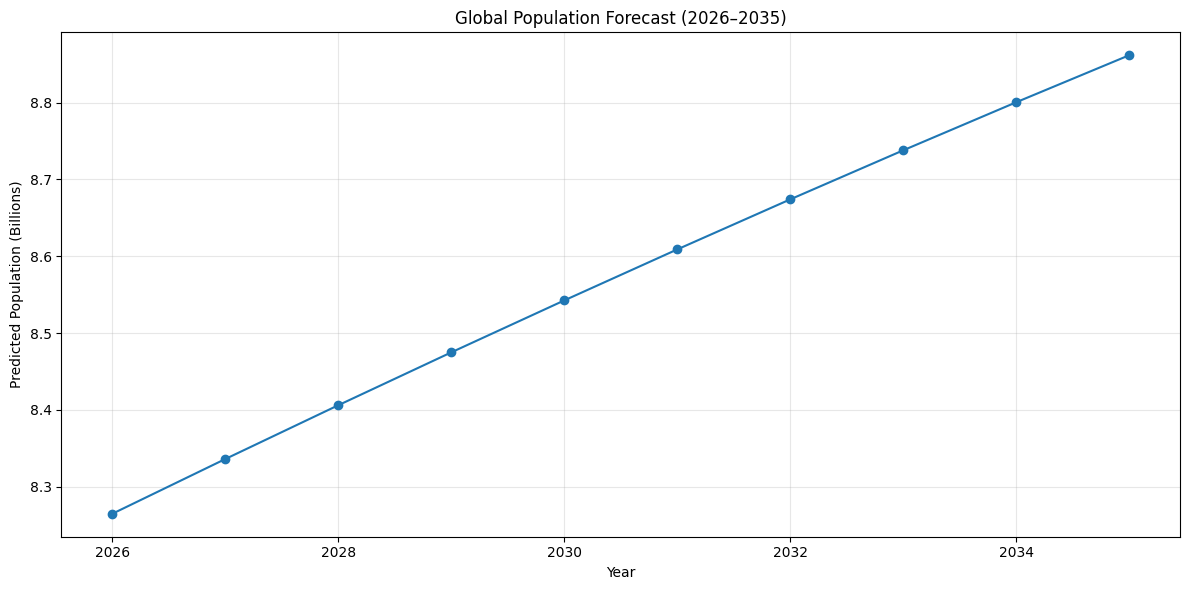

Final forecast visualization saved successfully.


In [48]:
# Final Global Population Forecast Visualization

plt.figure(figsize=(12, 6))

plt.plot(
    global_forecast["Year"],
    global_forecast["Predicted_Population_Billion"],
    marker="o"
)

plt.title(
    "Global Population Forecast (2026–2035)"
)

plt.xlabel("Year")
plt.ylabel("Predicted Population (Billions)")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/final_global_population_forecast_2026_2035.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final forecast visualization saved successfully.")